## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the indices such as NDVI, NDBI, NNDWI and BSI. The script with the computation of the LST can be found [here](https://github.com/EllenB/lstroad/blob/main/notebooks/03_lst_bangalore_band_10.ipynb) and the script for the indices [here](https://github.com/EllenB/lstroad/blob/main/notebooks/04_indices_bangalore.ipynb). 

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [3]:
lst_path = PROCESSED_DIR /'lstband10summer_chennai.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_chennai.csv


In [4]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [5]:
df_lst_mean_summer.head()

,system:index,zone_id,mean,zone_name,Name
0,0,13,40.361148,Adyar,168
1,1,13,39.219309,Adyar,169
2,2,13,37.738077,Adyar,170
3,3,13,37.393918,Adyar,171
4,4,13,37.216989,Adyar,174


In [6]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 37.03991818381252.
The maximum temperature is 44.48337828024445.


### Indices

In [7]:
indices_path = PROCESSED_DIR /'indices_wards_geemap_chennai.csv'
df_indices = pd.read_csv(indices_path)

In [8]:
df_indices.head()

,system:index,zone_id,MNDWI,BSI,NDBI,zone_name,NDVI,Name
0,0,13,-0.332298,0.043550,-0.030004,Adyar,0.330771,168
1,1,13,-0.349669,-0.017255,-0.093543,Adyar,0.416803,169
2,2,13,-0.338916,-0.038755,-0.115631,Adyar,0.428264,170
3,3,13,-0.181233,-0.052693,-0.145909,Adyar,0.340435,171
4,4,13,-0.274315,-0.064182,-0.138344,Adyar,0.410037,174


In [9]:
merged = pd.merge(df_lst_mean_summer, df_indices, on='Name')
merged.head()

,system:index_x,zone_id_x,mean,zone_name_x,Name,system:index_y,zone_id_y,MNDWI,BSI,NDBI,zone_name_y,NDVI
0,0,13,40.361148,Adyar,168,0,13,-0.332298,0.043550,-0.030004,Adyar,0.330771
1,1,13,39.219309,Adyar,169,1,13,-0.349669,-0.017255,-0.093543,Adyar,0.416803
2,2,13,37.738077,Adyar,170,2,13,-0.338916,-0.038755,-0.115631,Adyar,0.428264
3,3,13,37.393918,Adyar,171,3,13,-0.181233,-0.052693,-0.145909,Adyar,0.340435
4,4,13,37.216989,Adyar,174,4,13,-0.274315,-0.064182,-0.138344,Adyar,0.410037


Only retain the relevant variables and rename:

In [10]:
merged = merged[['zone_id_x', 'mean', 'zone_name_x', 'Name', 'MNDWI', 'NDBI', 'BSI', 'NDVI']]
merged.head()

,zone_id_x,mean,zone_name_x,Name,MNDWI,NDBI,BSI,NDVI
0,13,40.361148,Adyar,168,-0.332298,-0.030004,0.043550,0.330771
1,13,39.219309,Adyar,169,-0.349669,-0.093543,-0.017255,0.416803
2,13,37.738077,Adyar,170,-0.338916,-0.115631,-0.038755,0.428264
3,13,37.393918,Adyar,171,-0.181233,-0.145909,-0.052693,0.340435
4,13,37.216989,Adyar,174,-0.274315,-0.138344,-0.064182,0.410037


In [11]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'mean': 'mean_lst'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,MNDWI,NDBI,BSI,NDVI
0,13,40.361148,Adyar,168,-0.332298,-0.030004,0.043550,0.330771
1,13,39.219309,Adyar,169,-0.349669,-0.093543,-0.017255,0.416803
2,13,37.738077,Adyar,170,-0.338916,-0.115631,-0.038755,0.428264
3,13,37.393918,Adyar,171,-0.181233,-0.145909,-0.052693,0.340435
4,13,37.216989,Adyar,174,-0.274315,-0.138344,-0.064182,0.410037


## Correlations

In [12]:
vars_df = merged[[
    "mean_lst",
    "NDVI",
    "NDBI",
    "BSI",
    "MNDWI"
]].dropna()

In [13]:
corr = vars_df.corr(method="pearson")

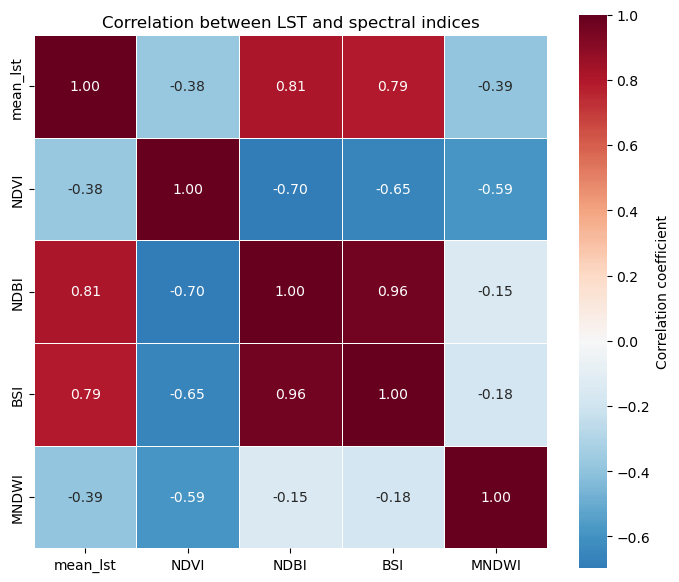

In [14]:
corr_path_indices = IMAGES_DIR / 'corr_indices_chennai.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()


#### NDVI

In [15]:
# x and y
x = merged[["NDVI"]]
Y = merged["mean_lst"]

In [16]:
fig_path = IMAGES_DIR / 'regression_chennai_NDVI.png'

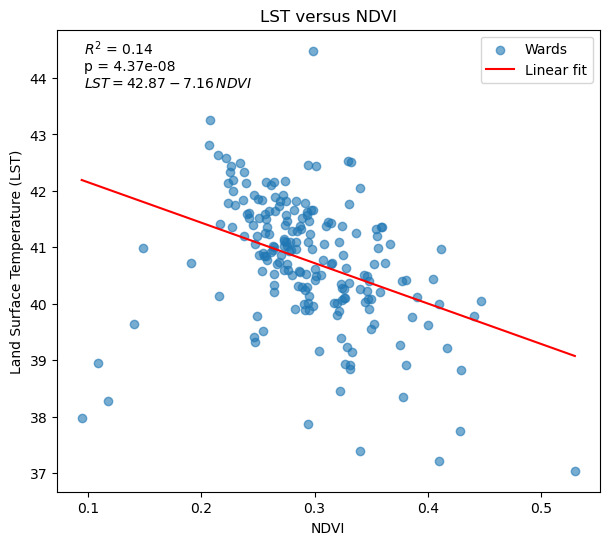

In [17]:
# x and y
x = merged["NDVI"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDVI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDVI")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,NDVI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [18]:
p_value

np.float64(4.3707803838404524e-08)

In [19]:
print(slope, intercept, r_value)

-7.164156037868736 42.86896386346876 -0.3752631983529165


In [20]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.3752631983529166), pvalue=np.float64(4.3707803838403915e-08))

In [21]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDVI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     32.45
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           4.37e-08
Time:                        22:30:46   Log-Likelihood:                -292.06
No. Observations:                 200   AIC:                             588.1
Df Residuals:                     198   BIC:                             594.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.8690      0.377    113.565      0.0

In [22]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.3752631983529166), pvalue=np.float64(4.3707803838403915e-08))

#### MNDWI

In [23]:
# x and y
x = merged["MNDWI"]
y = merged["mean_lst"]

In [24]:
fig_path = IMAGES_DIR / 'regression_chennai_MNDWI.png'

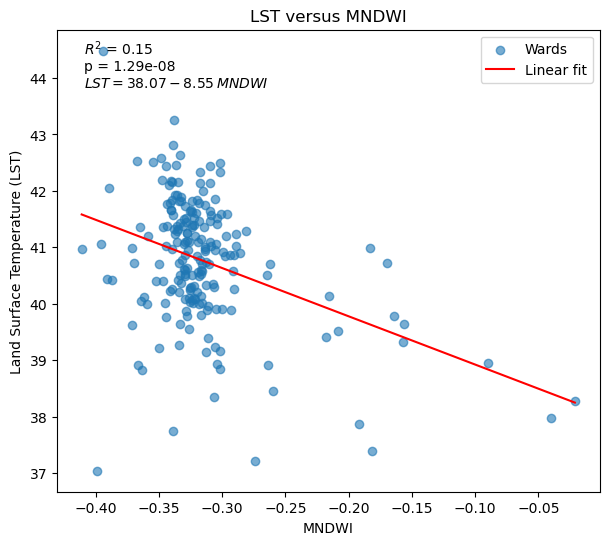

In [25]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("MNDWI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus MNDWI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,MNDWI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [26]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['MNDWI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     35.23
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.29e-08
Time:                        22:30:50   Log-Likelihood:                -290.86
No. Observations:                 200   AIC:                             585.7
Df Residuals:                     198   BIC:                             592.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.0661      0.460     82.777      0.0

In [27]:
pearsonr(merged['MNDWI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.388649764745733), pvalue=np.float64(1.2925419132758547e-08))

#### NDBI

In [28]:
# x and y
x = merged["NDBI"]
y = merged["mean_lst"]

In [29]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [30]:
fig_path = IMAGES_DIR / 'regression_chennai_NDBI.png'

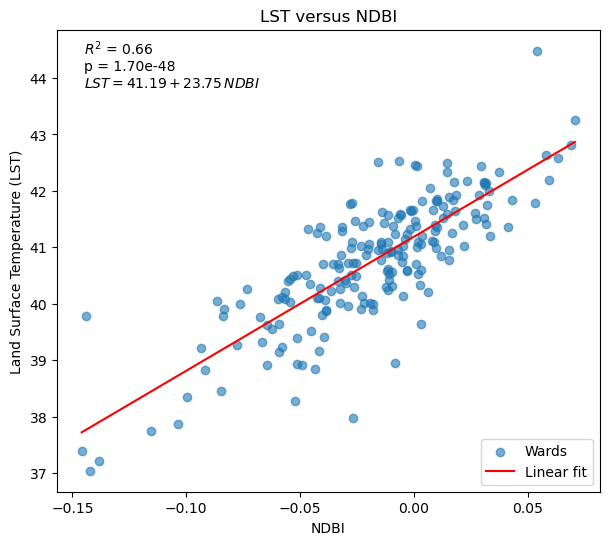

In [31]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDBI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,NDBI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [32]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDBI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     387.4
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.70e-48
Time:                        22:30:54   Log-Likelihood:                -198.83
No. Observations:                 200   AIC:                             401.7
Df Residuals:                     198   BIC:                             408.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.1865      0.051    803.381      0.0

In [33]:
pearsonr(merged['NDBI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.8135077858863097), pvalue=np.float64(1.699915904123802e-48))

#### BSI

In [34]:
# x and y
x = merged["BSI"]
y = merged["mean_lst"]

In [35]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [36]:
fig_path = IMAGES_DIR / 'regression_chennai_BSI.png'

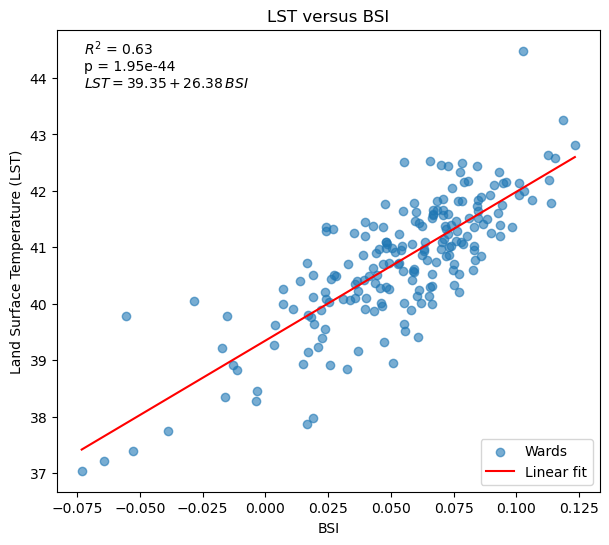

In [37]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("BSI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus BSI")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,BSI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [38]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['BSI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     334.8
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.95e-44
Time:                        22:30:58   Log-Likelihood:                -208.24
No. Observations:                 200   AIC:                             420.5
Df Residuals:                     198   BIC:                             427.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.3464      0.091    430.761      0.0

In [39]:
pearsonr(merged['BSI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.792715992409057), pvalue=np.float64(1.9512741901133085e-44))